# COSME 美妝評論季節 NLP 分析

這份 notebook 會先完成資料清洗、季節標記與 Jieba 斷詞，再依序做三個分析：產品訴求季節演變、品牌聲量季節性更迭，以及關鍵字生命週期。每一格都可以分開執行。

In [2]:
import re
from pathlib import Path

import jieba
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import font_manager
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

FONT_CANDIDATES = [
    r"C:\Windows\Fonts\msjh.ttc",
    r"C:\Windows\Fonts\msjhbd.ttc",
    r"C:\Windows\Fonts\mingliu.ttc",
    r"C:\Windows\Fonts\simsun.ttc",
]
FONT_PATH = next((font for font in FONT_CANDIDATES if Path(font).exists()), None)
if FONT_PATH:
    font_manager.fontManager.addfont(FONT_PATH)
    FONT_PROP = font_manager.FontProperties(fname=FONT_PATH)
    FONT_NAME = FONT_PROP.get_name()
    plt.rcParams["font.family"] = FONT_NAME
else:
    FONT_PROP = None

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
TEXT_COL = "內容"
BRAND_COL = "品牌"
MONTH_COL = "月份"
SEASON_ORDER = ["春", "夏", "秋", "冬"]
SEASON_MAP = {
    12: "冬", 1: "冬", 2: "冬",
    3: "春", 4: "春", 5: "春",
    6: "夏", 7: "夏", 8: "夏",
    9: "秋", 10: "秋", 11: "秋",
}

CUSTOM_WORDS = [
    "控油", "防曬", "保濕", "滋潤", "精華液", "面膜", "乳液", "化妝水",
    "資生堂", "適樂膚", "蘭蔻", "理膚寶水", "雅詩蘭黛", "小黑瓶", "安耐曬",
    "CeraVe", "SHISEIDO", "ESTEE", "LANCOME", "SKII", "Kiehl", "玻尿酸"
]
for word in CUSTOM_WORDS:
    jieba.add_word(word)

if Path("userdict.txt").exists():
    jieba.load_userdict("userdict.txt")

STOPWORDS = {
    "這款", "這個", "那個", "產品", "商品", "使用", "使用後", "真的", "非常", "覺得", "感覺",
    "比較", "有點", "可以", "不錯", "好用", "推薦", "試用", "目前", "之前", "之後", "一樣",
    "而且", "但是", "如果", "因為", "所以", "還有", "就是", "這次", "本來", "自己", "我們",
    "他們", "你們", "我覺得", "整體", "效果", "味道", "膚況", "臉上", "臉部", "肌膚", "保養",
    "適合", "回購", "回購率", "吸收", "吸收力", "質地", "味", "品牌", "專櫃", "開架", "大推","不會","謝謝","感謝","沒有","容易","超級",
    "起來","一直","完全","機會","提供","抽到","收到","感受","系列","需要","搭配","最近","未來"
}


def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^\u4e00-\u9fff]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text):
    text = clean_text(text)
    tokens = []
    for word in jieba.lcut(text):
        token = word.strip()
        if not token:
            continue
        if len(token) == 1:
            continue
        if token in STOPWORDS:
            continue
        if re.fullmatch(r"\d+", token):
            continue
        tokens.append(token)
    return " ".join(tokens)


def month_to_season(month_value):
    if pd.isna(month_value):
        return np.nan
    month_text = str(month_value).strip()
    month_dt = pd.to_datetime(month_text, format="%Y/%m", errors="coerce")
    if pd.isna(month_dt):
        month_dt = pd.to_datetime(month_text, errors="coerce")
    if pd.isna(month_dt):
        return np.nan
    return SEASON_MAP.get(int(month_dt.month), np.nan)


def normalize_brand_name(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    text = re.sub(r"[（）()\[\]【】]", " ", text)
    parts = [part for part in re.split(r"\s+", text) if part]
    candidate = parts[-1] if parts else text
    candidate = re.sub(r"[^\u4e00-\u9fffA-Za-z0-9\-&+]+", "", candidate)
    return candidate or text


def get_tfidf_scores(df_subset, text_column="tokenized_text", min_df=1, ngram_range=(1, 1)):
    texts = df_subset[text_column].fillna("").astype(str).tolist()
    texts = [text for text in texts if text.strip()]
    if not texts:
        return pd.Series(dtype=float)
    vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        min_df=min_df,
        max_df=0.95,
        ngram_range=ngram_range,
    )
    matrix = vectorizer.fit_transform(texts)
    scores = matrix.mean(axis=0).A1
    return pd.Series(scores, index=vectorizer.get_feature_names_out()).sort_values(ascending=False)


csv_files = sorted(DATA_DIR.glob("cosme_reviews[[]*.csv"))
frames = []
for file_path in csv_files:
    frames.append(pd.read_csv(file_path, encoding="utf-8-sig"))

if not frames:
    raise FileNotFoundError("data/ 底下找不到 cosme_reviews[YYYY-MM].csv")

data = pd.concat(frames, ignore_index=True)
data[MONTH_COL] = data[MONTH_COL].astype(str)
data["season"] = data[MONTH_COL].apply(month_to_season)
data["clean_text"] = data[TEXT_COL].apply(clean_text)
data["tokenized_text"] = data["clean_text"].apply(tokenize)
data["brand_label"] = data[BRAND_COL].apply(normalize_brand_name)
data["brand_enriched_text"] = data["brand_label"].fillna("") + " " + data["tokenized_text"].fillna("")
data = data[data["season"].isin(SEASON_ORDER)].copy()

def season_tfidf_scores(df_subset, text_column="tokenized_text", min_df=1, ngram_range=(1, 1)):
    return get_tfidf_scores(df_subset, text_column=text_column, min_df=min_df, ngram_range=ngram_range)

print(f"資料筆數：{len(data):,}")
print("季節分佈：")
display(data["season"].value_counts().reindex(SEASON_ORDER))
display(data[[BRAND_COL, TEXT_COL, MONTH_COL, "season", "clean_text", "tokenized_text"]].head())

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\mike\AppData\Local\Temp\jieba.cache
Loading model cost 0.856 seconds.
Prefix dict has been built successfully.


資料筆數：7,855
季節分佈：


season
春    2729
夏    1687
秋    2117
冬    1322
Name: count, dtype: int64

,品牌,內容,月份,season,clean_text,tokenized_text
0,LANCÔME 蘭蔻,當初看到網路介紹很吸引我 在官網留個人資料申請試用包 但是現在母親節檔期前 專櫃人員說：無法...,2025/05,春,當初看到網路介紹很吸引我 在官網留個人資料申請試用包 但是現在母親節檔期前 專櫃人員說 無法...,當初 看到 網路 介紹 吸引 官網 留個 資料 申請 現在母 親節 檔期 人員 無法 兌換 ...
1,LANCÔME 蘭蔻,在@cosme夏季交流會上試用到這款產品 是2025台灣新秀賞 眼霜排行榜 NO. 1其實自...,2025/05,春,在 夏季交流會上試用到這款產品 是 台灣新秀賞 眼霜排行榜 其實自己也關注這瓶眼霜很久了 只...,夏季 交流 上試 用到 台灣 新秀 眼霜 排行榜 其實 關注 這瓶 眼霜 很久 只是 家裡 ...
2,LANCÔME 蘭蔻,首先要先感謝「cosme」及「蘭蔻」，提供此抽獎活動讓我有機會搶先體驗新產品，本人深感榮幸💖...,2025/05,春,首先要先感謝 及 蘭蔻 提供此抽獎活動讓我有機會搶先體驗新產品 本人深感榮幸 先附上產品圖片...,首先 蘭蔻 抽獎 活動 先體驗 新產品 本人 深感 榮幸 附上 圖片 小黑 眼霜 另外 三包...
3,LANCÔME 蘭蔻,百貨週年慶在專櫃購物時試試～ 買東西櫃姐送的試用包～質地是白色無流動性的凝霜狀，氣味是肌因系...,2025/05,春,百貨週年慶在專櫃購物時試試 買東西櫃姐送的試用包 質地是白色無流動性的凝霜狀 氣味是肌因系列...,百貨 週年慶 購物時 試試 買東 西櫃姐 白色 無流動性 凝霜 氣味 肌因 氣味 不香 用久...
4,LANCÔME 蘭蔻,以前就使用過小黑眼霜 這次很開心有機會體驗小黑眼霜的升級版 身為踏入30大關的女子來說眼周保...,2025/05,春,以前就使用過小黑眼霜 這次很開心有機會體驗小黑眼霜的升級版 身為踏入 大關的女子來說眼周保養...,以前 小黑 眼霜 開心 體驗 小黑 眼霜 升級 身為 踏入 大關 女子 眼周 保養勢 必是 ...


## Cell 1. 資料讀取與 NLP 預處理

這一格會讀取 `data/` 底下的 `cosme_reviews[YYYY-MM].csv`，建立 `season` 欄位，並產生 `clean_text` 與 `tokenized_text`。

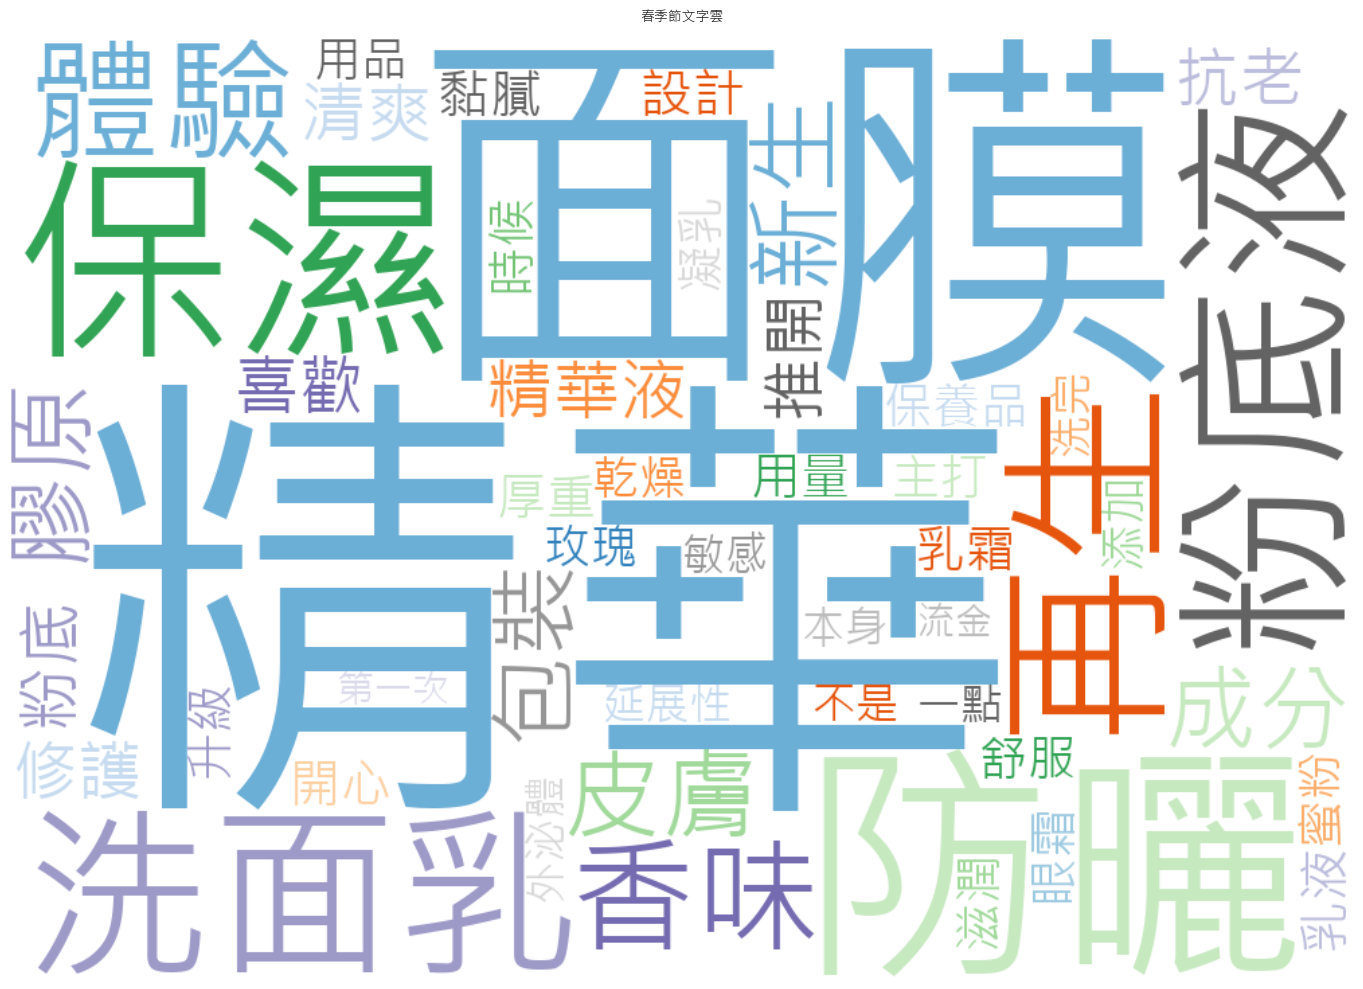

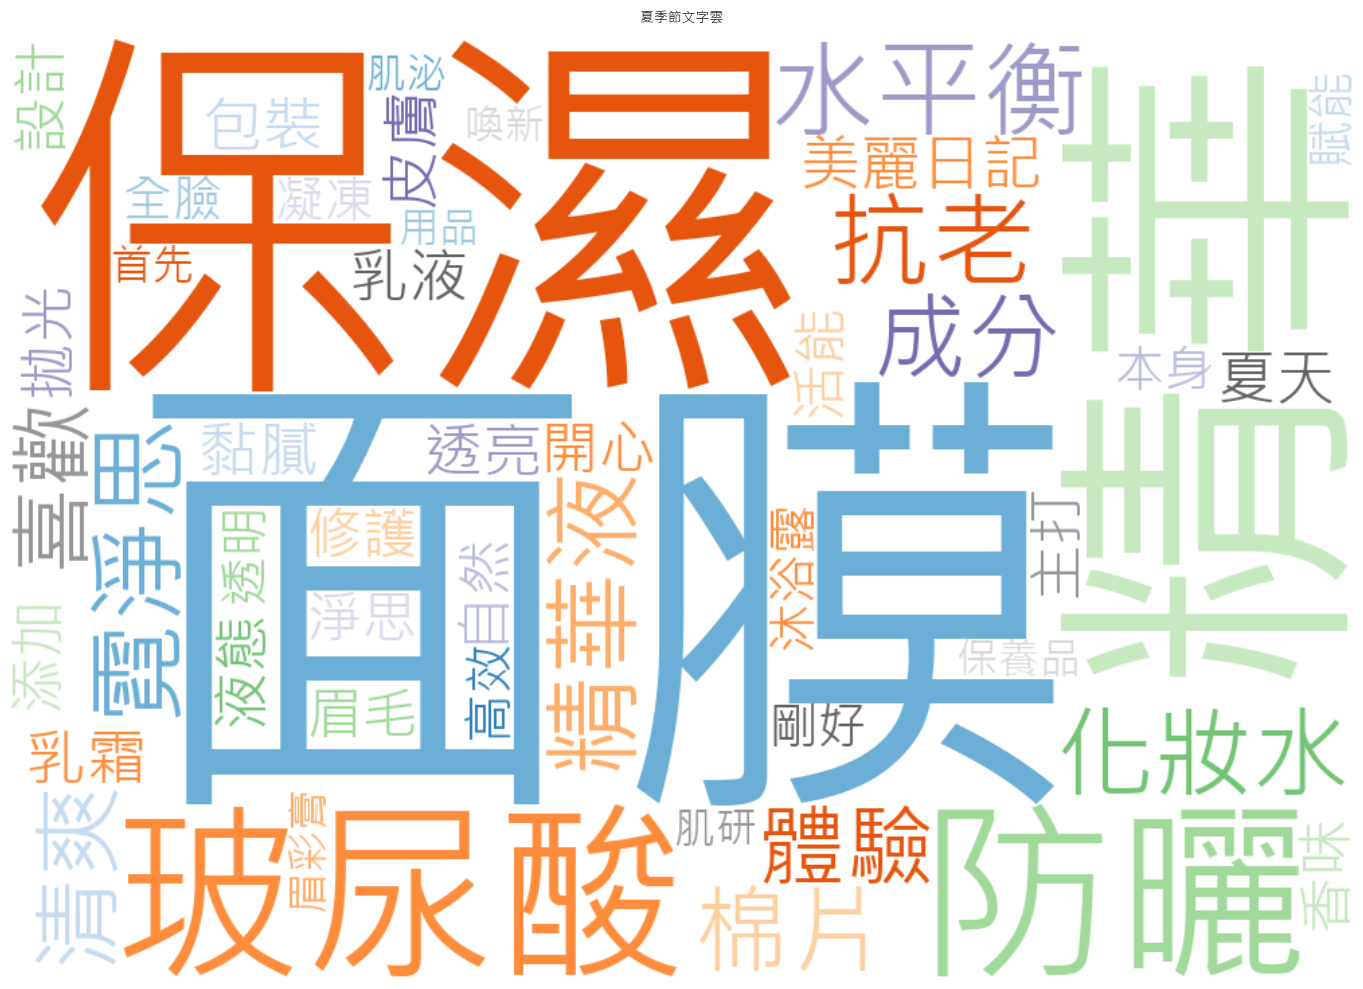

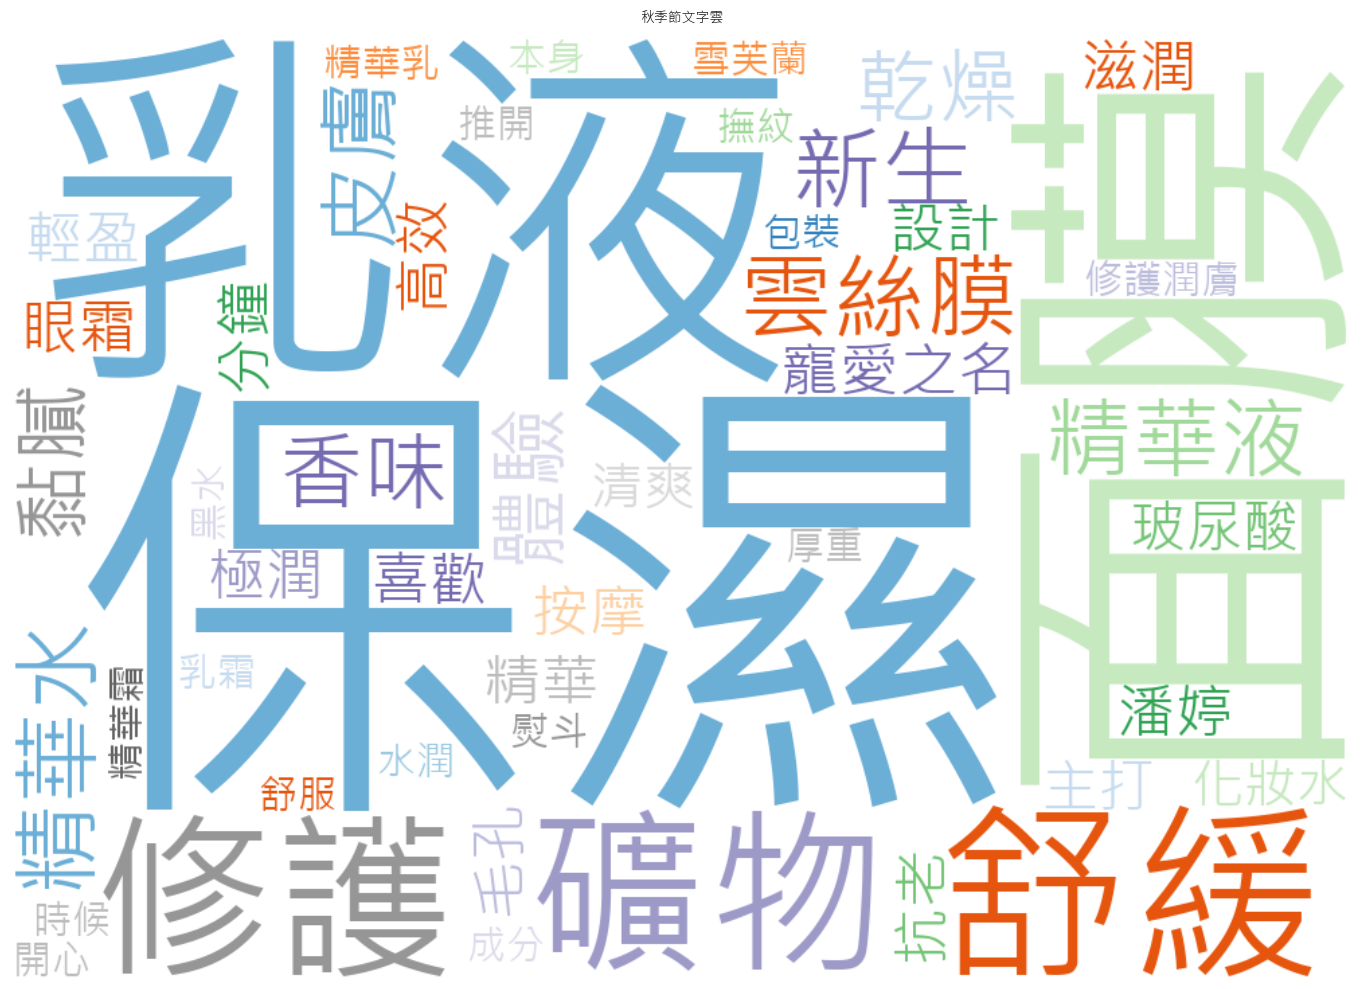

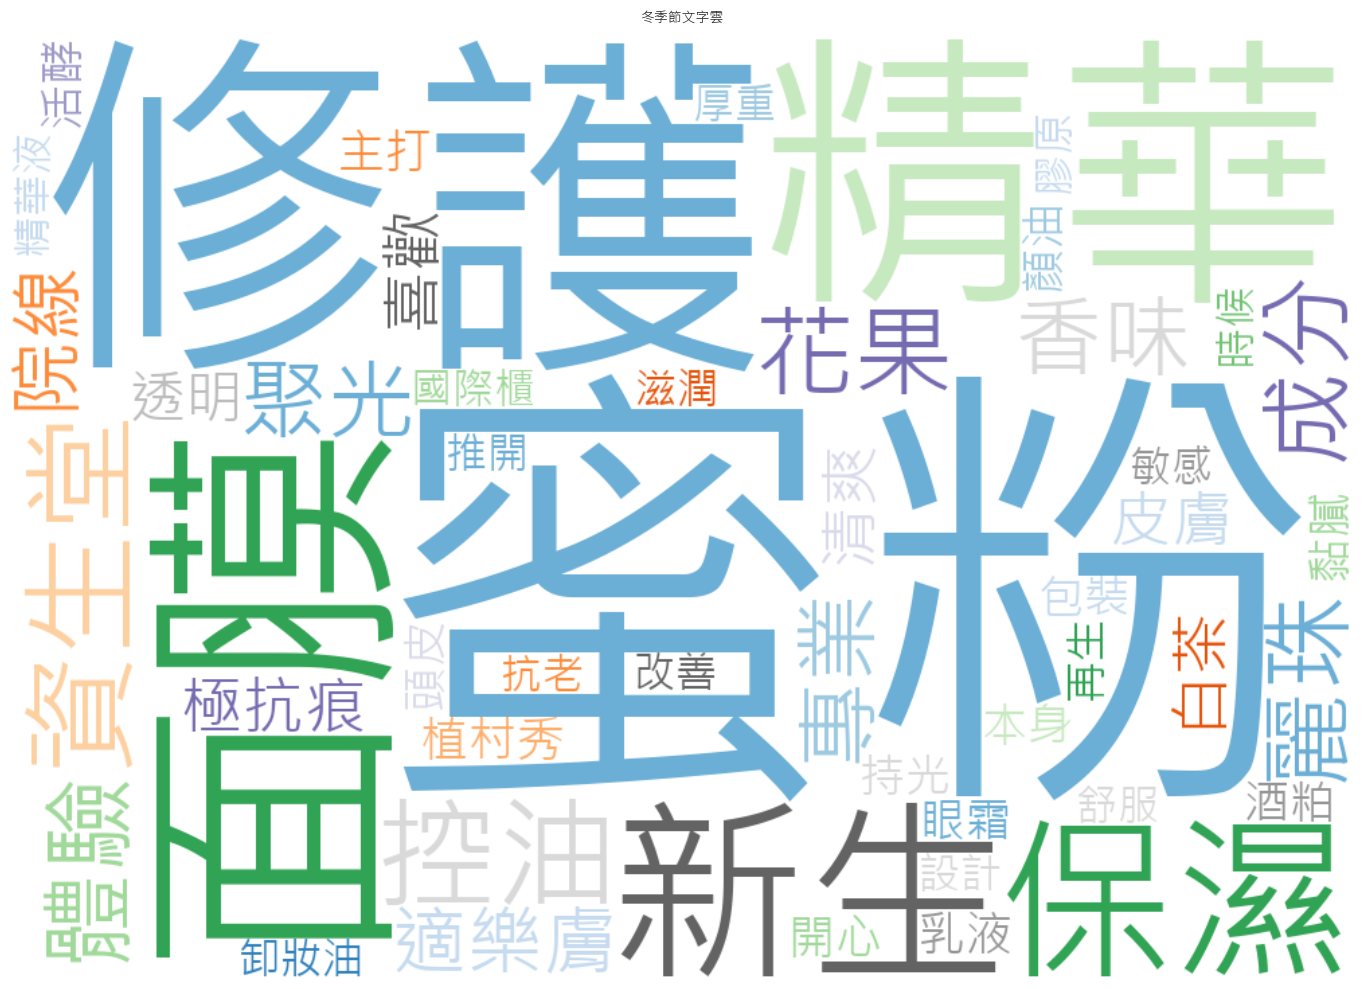

In [3]:
season_palette = {
    "春": "#5B8E7D",
    "夏": "#E7A62E",
    "秋": "#B5654D",
    "冬": "#4C78A8",
}

season_scores_map = {}
for season in SEASON_ORDER:
    df_season = data[data["season"] == season]
    season_scores_map[season] = season_tfidf_scores(df_season, text_column="tokenized_text", min_df=1, ngram_range=(1, 1))

for idx, season in enumerate(SEASON_ORDER):
    plt.figure(figsize=(14, 10))
    ax_wordcloud = plt.gca()
    season_scores = season_scores_map[season]

    if season_scores.empty:
        ax_wordcloud.text(0.5, 0.5, f"{season}季沒有足夠資料", ha="center", va="center")
        ax_wordcloud.axis("off")
        continue

    if FONT_PATH is None:
        raise FileNotFoundError("找不到可用的中文字型，請確認 Windows Fonts 是否包含 msjh.ttc 或其他中文字型。")

    wc = WordCloud(
        font_path=FONT_PATH,
        background_color="white",
        max_words=80,
        width=1000,
        height=700,
        colormap="tab20c",
        random_state=42,
        prefer_horizontal=0.9,
    )
    wc.generate_from_frequencies(season_scores.head(50).to_dict())
    ax_wordcloud.imshow(wc, interpolation="bilinear")
    ax_wordcloud.axis("off")
    ax_wordcloud.set_title(f"{season}季節文字雲", fontsize=18, pad=12, fontproperties=FONT_PROP)
    plt.tight_layout()
    plt.show()


## Cell 3. 任務二 - 品牌聲量季節性更迭（熱力圖 Heatmap）

篩選出 TF-IDF 分數較高的代表性品牌，建立品牌 x 季節的 Pivot Table，並用 heatmap 呈現討論熱度。

season,春,夏,秋,冬
霓淨思,0.0105,0.0374,0.0000,0.0107
適樂膚,0.0137,0.0000,0.0004,0.0243
雪芙蘭,0.0000,0.0148,0.0218,0.0000
植村秀,0.0071,0.0000,0.0002,0.0230
肌研,0.0003,0.0162,0.0000,0.0137
赫蓮娜,0.0122,0.0087,0.0074,0.0000
寵愛之名,0.0000,0.0000,0.0276,0.0000
蘭蔻,0.0053,0.0000,0.0147,0.0057


c:\Users\mike\Desktop\NLP FINAL\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 26149 (\N{CJK UNIFIED IDEOGRAPH-6625}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\mike\Desktop\NLP FINAL\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 22799 (\N{CJK UNIFIED IDEOGRAPH-590F}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\mike\Desktop\NLP FINAL\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 31179 (\N{CJK UNIFIED IDEOGRAPH-79CB}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\mike\Desktop\NLP FINAL\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 20908 (\N{CJK UNIFIED IDEOGRAPH-51AC}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\mike\Desktop\NLP FINAL\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 38675 (\N{CJK UNIFIED IDEOGRAPH-9713}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\mike\Desktop\NLP FINAL\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarn

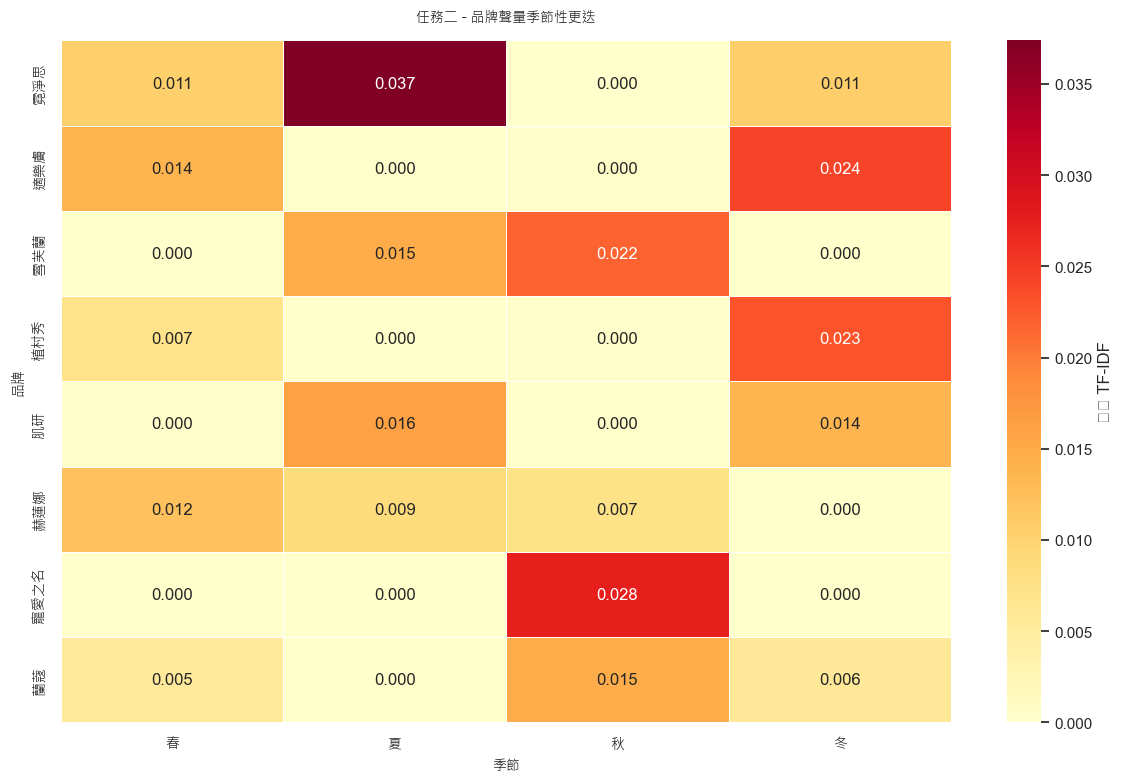

In [4]:
# 自動選出候選品牌：依據資料中品牌出現頻率挑前幾名（此處取前 50 作為候選）
brand_freq = data["brand_label"].value_counts()
brand_candidates = brand_freq.index.tolist()[:50]

brand_season_rows = []
for season in SEASON_ORDER:
    df_season = data[data["season"] == season]
    season_scores = season_tfidf_scores(df_season, text_column="brand_enriched_text", min_df=1, ngram_range=(1, 1))
    row = {brand: float(season_scores.get(brand, 0.0)) for brand in brand_candidates}
    row["season"] = season
    brand_season_rows.append(row)

brand_tfidf_by_season = pd.DataFrame(brand_season_rows).set_index("season").reindex(SEASON_ORDER)
brand_rank = brand_tfidf_by_season.mean(axis=0).sort_values(ascending=False)

# 自動決定要取幾個 top brands：預設 8，但若有效（>0）品牌數量不足則取實際數量
if brand_rank.empty:
    top_brands = []
else:
    nonzero_count = int((brand_rank > 0).sum())
    k = min(8, nonzero_count) if nonzero_count > 0 else min(8, len(brand_rank))
    top_brands = brand_rank.head(k).index.tolist()
heatmap_df = brand_tfidf_by_season[top_brands].T.reindex(top_brands)

display(heatmap_df.round(4))

ax = plt.figure(figsize=(12, 8)).gca()
sns.heatmap(
    heatmap_df.fillna(0),
    cmap="YlOrRd",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "平均 TF-IDF"},
    ax=ax,
)
ax.set_title("任務二 - 品牌聲量季節性更迭", fontsize=18, pad=14, fontproperties=FONT_PROP)
ax.set_xlabel("季節", fontproperties=FONT_PROP)
ax.set_ylabel("品牌", fontproperties=FONT_PROP)
for label in ax.get_xticklabels():
    label.set_fontproperties(FONT_PROP)
for label in ax.get_yticklabels():
    label.set_fontproperties(FONT_PROP)
plt.tight_layout()
plt.show()

## Cell 4. 任務三 - 關鍵字生命週期（多線趨勢圖 Line Chart）

追蹤 `精華液`、`防曬`、`面膜` 在春、夏、秋、冬四季的 TF-IDF 變化，並在折線上加上數據標籤。

,精華液,防曬,面膜
春,0.0128,0.0228,0.0232
夏,0.0194,0.0259,0.0434
秋,0.0176,0.0021,0.0266
冬,0.0103,0.0054,0.0195


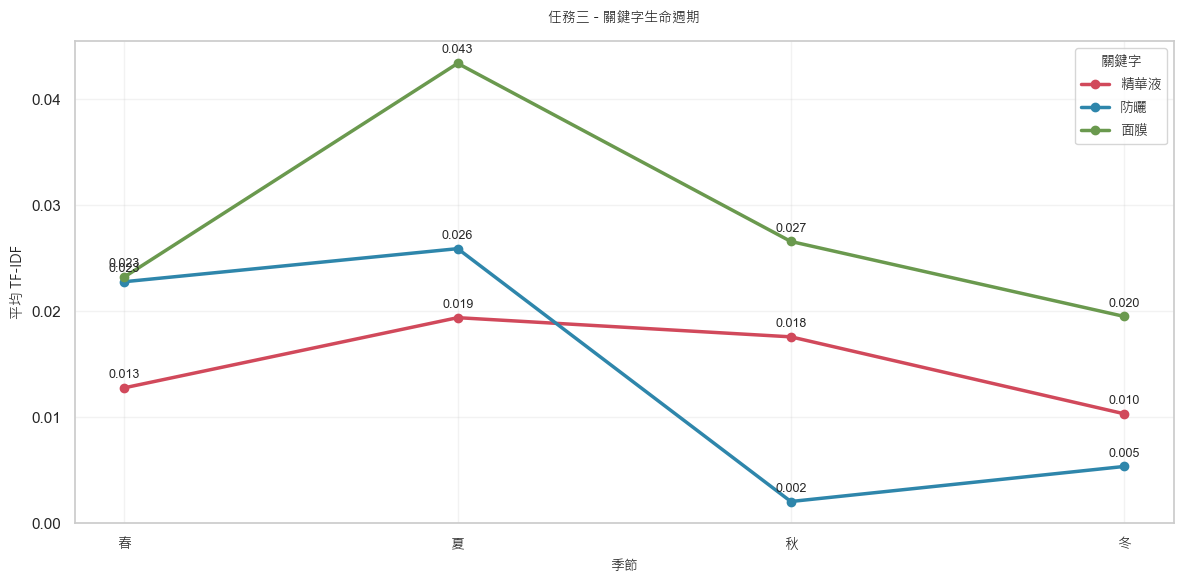

In [5]:
keywords = ["精華液", "防曬", "面膜"]
keyword_trend_df = pd.DataFrame(index=SEASON_ORDER, columns=keywords, dtype=float)

for season in SEASON_ORDER:
    df_season = data[data["season"] == season]
    season_scores = season_tfidf_scores(df_season, text_column="tokenized_text", min_df=1, ngram_range=(1, 1))
    for keyword in keywords:
        keyword_trend_df.loc[season, keyword] = float(season_scores.get(keyword, 0.0))

display(keyword_trend_df.round(4))

plt.figure(figsize=(12, 6))
ax = plt.gca()
line_colors = {
    "精華液": "#D1495B",
    "防曬": "#2E86AB",
    "面膜": "#6A994E",
}

for keyword in keywords:
    ax.plot(
        SEASON_ORDER,
        keyword_trend_df[keyword],
        marker="o",
        linewidth=2.5,
        label=keyword,
        color=line_colors[keyword],
    )
    for x_idx, value in enumerate(keyword_trend_df[keyword]):
        ax.text(x_idx, value + max(keyword_trend_df.max()) * 0.015, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_title("任務三 - 關鍵字生命週期", fontsize=18, pad=14, fontproperties=FONT_PROP)
ax.set_xlabel("季節", fontproperties=FONT_PROP)
ax.set_ylabel("平均 TF-IDF", fontproperties=FONT_PROP)
ax.set_xticks(range(len(SEASON_ORDER)))
ax.set_xticklabels(SEASON_ORDER)
for label in ax.get_xticklabels():
    label.set_fontproperties(FONT_PROP)
ax.set_ylim(bottom=0)
ax.legend(title="關鍵字", prop=FONT_PROP, title_fontproperties=FONT_PROP)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()